# 📊 LINCS L1000 × BindingDB – Analiza połączonego zbioru danych

Notebook eksplorujący zbiór danych powstały z połączenia BindingDB (DTI) z profilami ekspresji genowej LINCS L1000.

**Plik:** `datasets/clean_with_lincs.parquet`  
**Wymiary GE:** 978 landmark genes  
**Klucz łączenia:** Canonical SMILES (RDKit)

In [10]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

%matplotlib inline

## 1. Wczytanie danych i podstawowe statystyki

In [11]:
df = pl.read_parquet('datasets/clean_with_lincs.parquet')
df_orig = pl.read_parquet('datasets/clean.parquet')

ge_cols = [c for c in df.columns if c.startswith('ge_')]
non_ge_cols = [c for c in df.columns if not c.startswith('ge_')]

print('=' * 60)
print('PODSUMOWANIE ZBIORU DANYCH')
print('=' * 60)
print(f'Oryginalny BindingDB:     {df_orig.height:>10,} par DTI')
print(f'Po połączeniu z LINCS:    {df.height:>10,} par DTI')
print(f'Pokrycie:                 {100*df.height/df_orig.height:>9.1f}%')
print(f'\nUnikalne SMILES:           {df["Ligand SMILES"].n_unique():>10,}')
print(f'Unikalne białka:           {df["Full_Protein_Sequence"].n_unique():>10,}')
print(f'Kolumny GE:                {len(ge_cols):>10}')
print(f'Kolumny nie-GE:            {non_ge_cols}')
print(f'\nShape: {df.shape}')

PODSUMOWANIE ZBIORU DANYCH
Oryginalny BindingDB:        451,858 par DTI
Po połączeniu z LINCS:        27,496 par DTI
Pokrycie:                       6.1%

Unikalne SMILES:                8,400
Unikalne białka:                1,827
Kolumny GE:                       978
Kolumny nie-GE:            ['Ligand SMILES', 'Full_Protein_Sequence', 'Ki (nM)', 'pKi', 'is_active', 'canon_smiles', 'tanimoto_score']

Shape: (27496, 985)


## 2. Rozkład klas aktywności

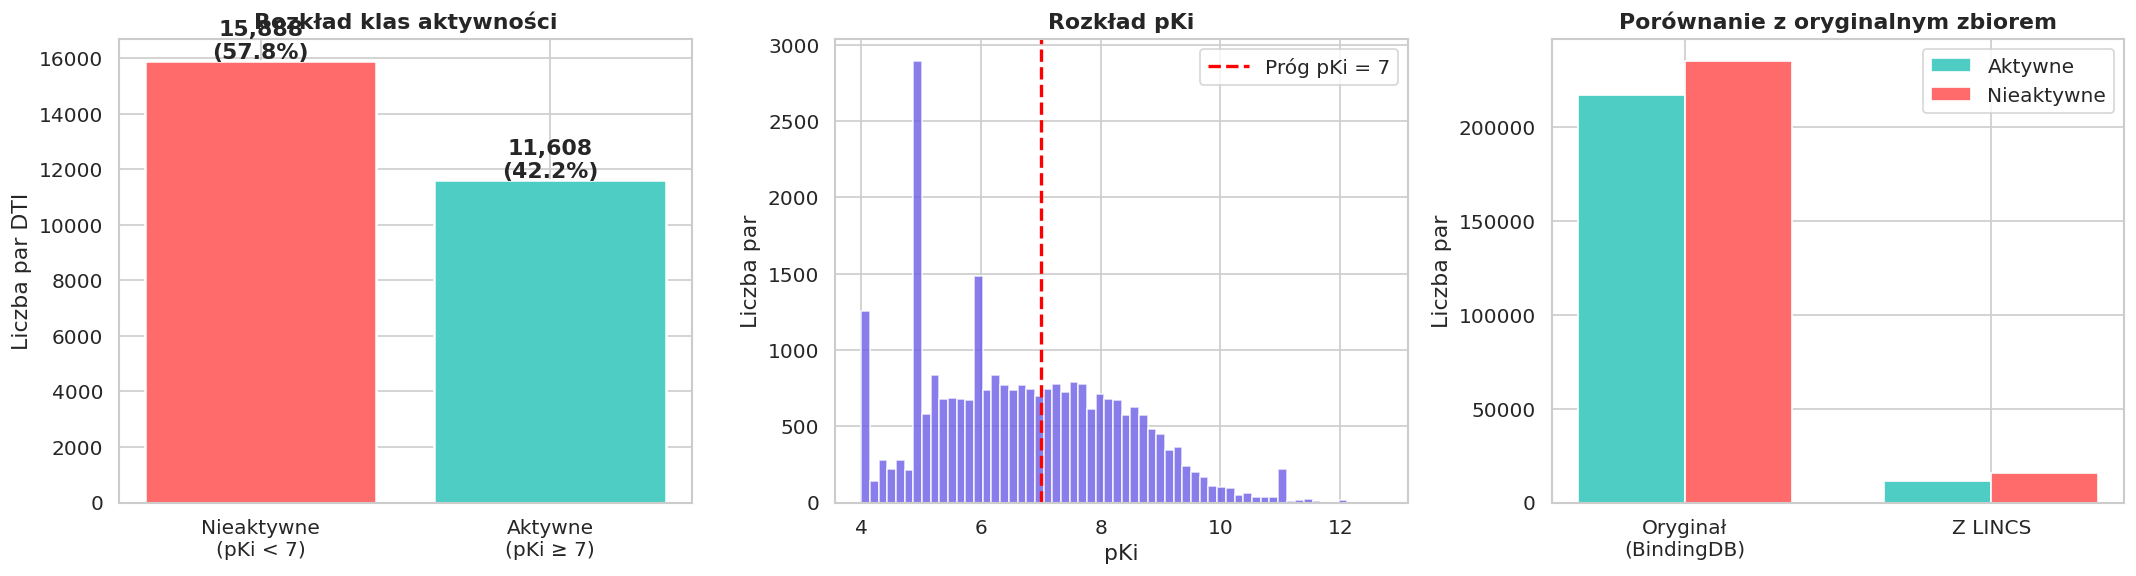

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2a: Active vs Inactive
active_counts = df['is_active'].value_counts().sort('is_active')
labels = ['Nieaktywne\n(pKi < 7)', 'Aktywne\n(pKi ≥ 7)']
counts = active_counts['count'].to_list()
colors = ['#FF6B6B', '#4ECDC4']
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{count:,}\n({100*count/df.height:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Rozkład klas aktywności', fontweight='bold')
axes[0].set_ylabel('Liczba par DTI')

# 2b: pKi distribution
pki = df['pKi'].to_numpy()
axes[1].hist(pki, bins=60, color='#6C5CE7', alpha=0.8, edgecolor='white')
axes[1].axvline(7.0, color='red', linestyle='--', linewidth=2, label='Próg pKi = 7')
axes[1].set_title('Rozkład pKi', fontweight='bold')
axes[1].set_xlabel('pKi')
axes[1].set_ylabel('Liczba par')
axes[1].legend()

# 2c: Comparison with original
categories = ['Oryginał\n(BindingDB)', 'Z LINCS']
orig_active = df_orig.filter(pl.col('is_active')).height
orig_inactive = df_orig.filter(~pl.col('is_active')).height
lincs_active = df.filter(pl.col('is_active')).height
lincs_inactive = df.filter(~pl.col('is_active')).height

x = np.arange(len(categories))
w = 0.35
axes[2].bar(x - w/2, [orig_active, lincs_active], w, label='Aktywne', color='#4ECDC4')
axes[2].bar(x + w/2, [orig_inactive, lincs_inactive], w, label='Nieaktywne', color='#FF6B6B')
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories)
axes[2].set_title('Porównanie z oryginalnym zbiorem', fontweight='bold')
axes[2].set_ylabel('Liczba par')
axes[2].legend()

plt.tight_layout()
plt.savefig('datasets/lincs_eda_activity.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rozkłady długości SMILES i białek

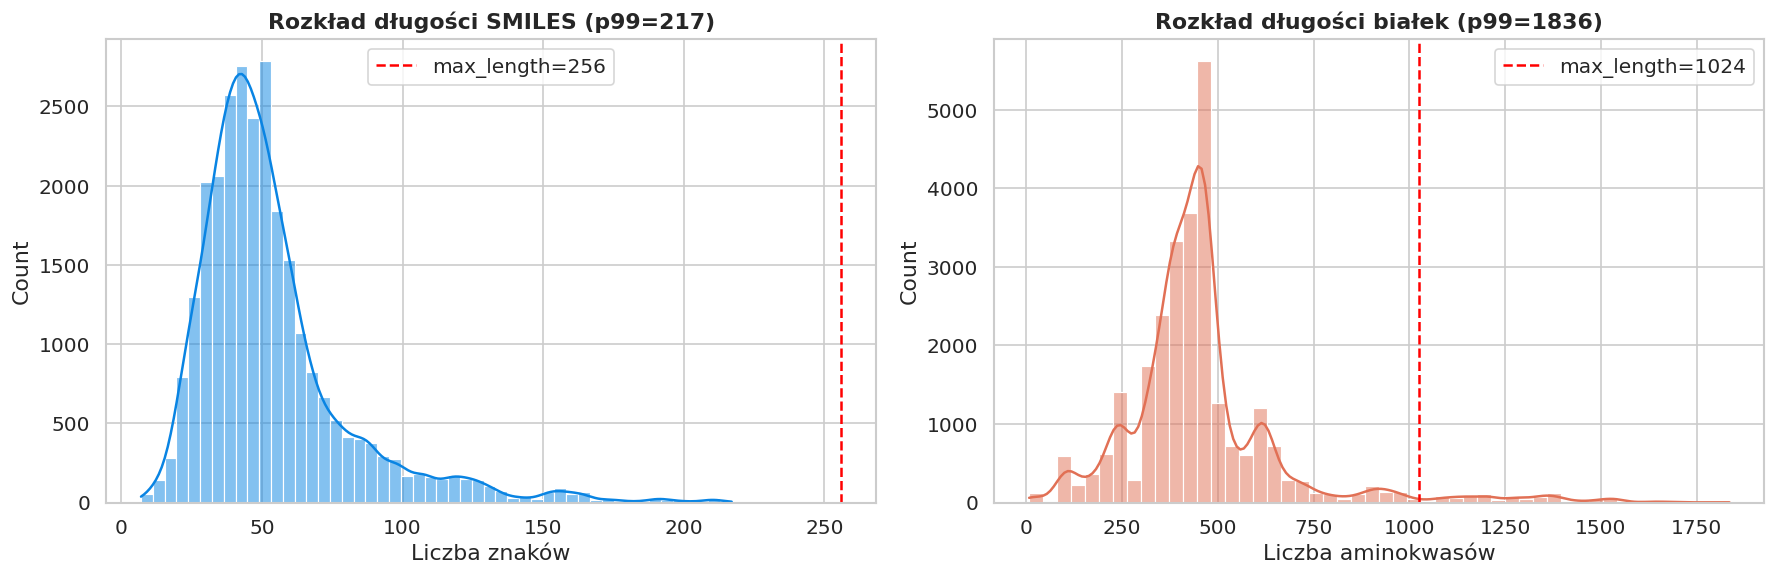

SMILES obcięte przy 256: 0.50%
Białka obcięte przy 1024: 4.16%


In [13]:
df2 = df.with_columns([
    pl.col('Ligand SMILES').str.len_chars().alias('SMILES_len'),
    pl.col('Full_Protein_Sequence').str.len_chars().alias('Protein_len')
])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sp99 = df2['SMILES_len'].quantile(0.99)
pp99 = df2['Protein_len'].quantile(0.99)

sns.histplot(df2.filter(pl.col('SMILES_len') <= sp99)['SMILES_len'].to_numpy(),
             bins=50, ax=axes[0], color='#0984E3', kde=True)
axes[0].axvline(256, color='red', linestyle='--', label='max_length=256')
axes[0].set_title(f'Rozkład długości SMILES (p99={int(sp99)})', fontweight='bold')
axes[0].set_xlabel('Liczba znaków')
axes[0].legend()

sns.histplot(df2.filter(pl.col('Protein_len') <= pp99)['Protein_len'].to_numpy(),
             bins=50, ax=axes[1], color='#E17055', kde=True)
axes[1].axvline(1024, color='red', linestyle='--', label='max_length=1024')
axes[1].set_title(f'Rozkład długości białek (p99={int(pp99)})', fontweight='bold')
axes[1].set_xlabel('Liczba aminokwasów')
axes[1].legend()

plt.tight_layout()
plt.savefig('datasets/lincs_eda_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

scut = df2.filter(pl.col('SMILES_len') > 256).height / df2.height * 100
pcut = df2.filter(pl.col('Protein_len') > 1024).height / df2.height * 100
print(f'SMILES obcięte przy 256: {scut:.2f}%')
print(f'Białka obcięte przy 1024: {pcut:.2f}%')

## 4. Profil ekspresji genowej (978 landmark genes)

Każdy związek chemiczny ma przypisany 978-wymiarowy wektor z-score'ów z LINCS L1000.

Macierz GE: (27496, 978)
Mean:  0.0016
Std:   0.5621
Min:   -10.0000
Max:   10.0000
NaN:   0


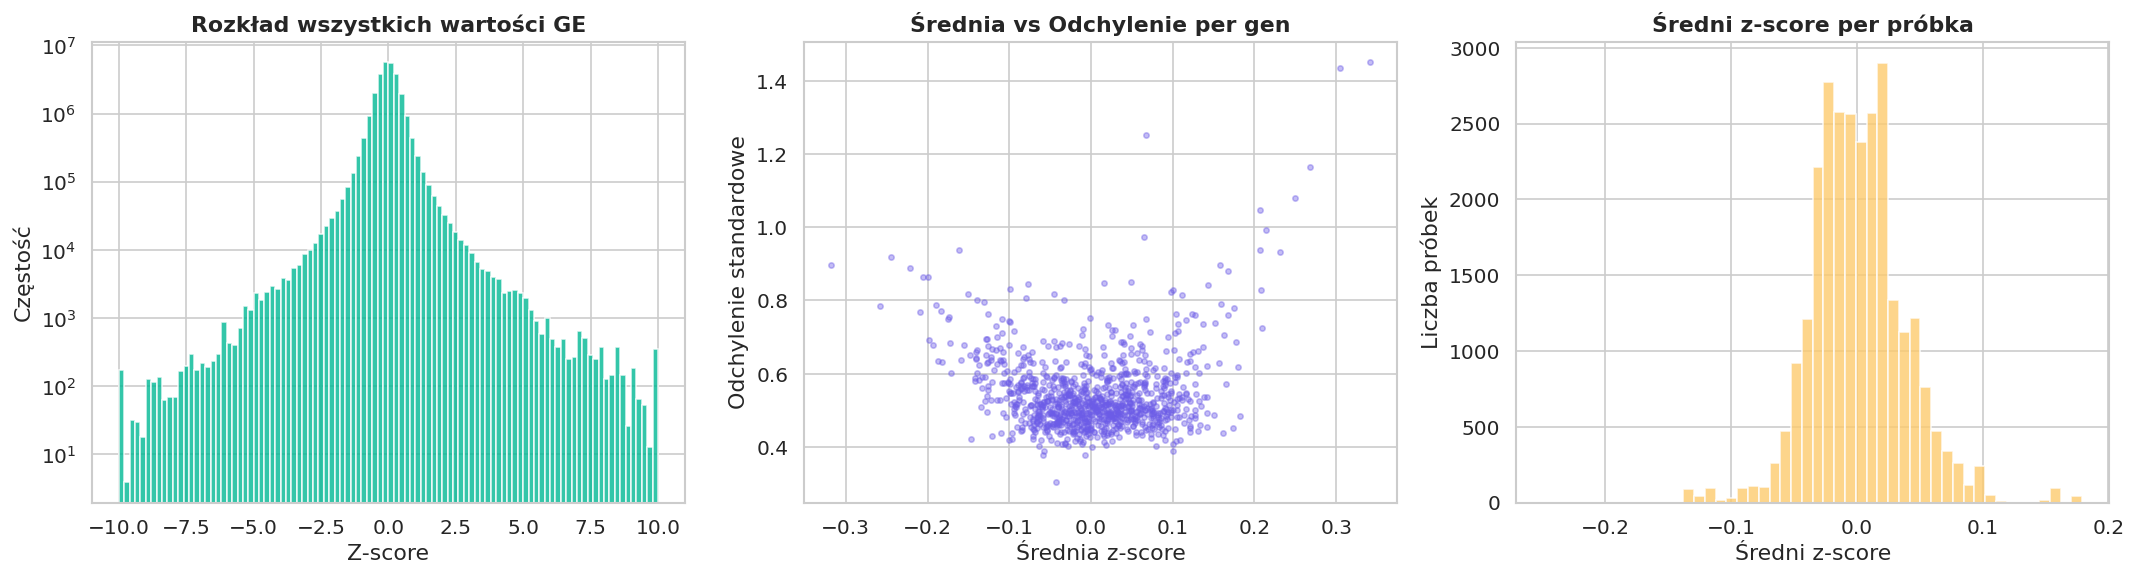

In [14]:
ge_matrix = df.select(ge_cols).to_numpy()
print(f'Macierz GE: {ge_matrix.shape}')
print(f'Mean:  {np.mean(ge_matrix):.4f}')
print(f'Std:   {np.std(ge_matrix):.4f}')
print(f'Min:   {np.min(ge_matrix):.4f}')
print(f'Max:   {np.max(ge_matrix):.4f}')
print(f'NaN:   {np.isnan(ge_matrix).sum()}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4a: Overall distribution of GE values
axes[0].hist(ge_matrix.flatten(), bins=100, color='#00B894', alpha=0.8, edgecolor='white')
axes[0].set_title('Rozkład wszystkich wartości GE', fontweight='bold')
axes[0].set_xlabel('Z-score')
axes[0].set_ylabel('Częstość')
axes[0].set_yscale('log')

# 4b: Mean expression per gene
gene_means = np.mean(ge_matrix, axis=0)
gene_stds = np.std(ge_matrix, axis=0)
axes[1].scatter(gene_means, gene_stds, alpha=0.4, s=10, color='#6C5CE7')
axes[1].set_title('Średnia vs Odchylenie per gen', fontweight='bold')
axes[1].set_xlabel('Średnia z-score')
axes[1].set_ylabel('Odchylenie standardowe')

# 4c: Mean expression per sample
sample_means = np.mean(ge_matrix, axis=1)
axes[2].hist(sample_means, bins=50, color='#FDCB6E', alpha=0.8, edgecolor='white')
axes[2].set_title('Średni z-score per próbka', fontweight='bold')
axes[2].set_xlabel('Średni z-score')
axes[2].set_ylabel('Liczba próbek')

plt.tight_layout()
plt.savefig('datasets/lincs_eda_ge_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Najbardziej zmienne geny (top 20)

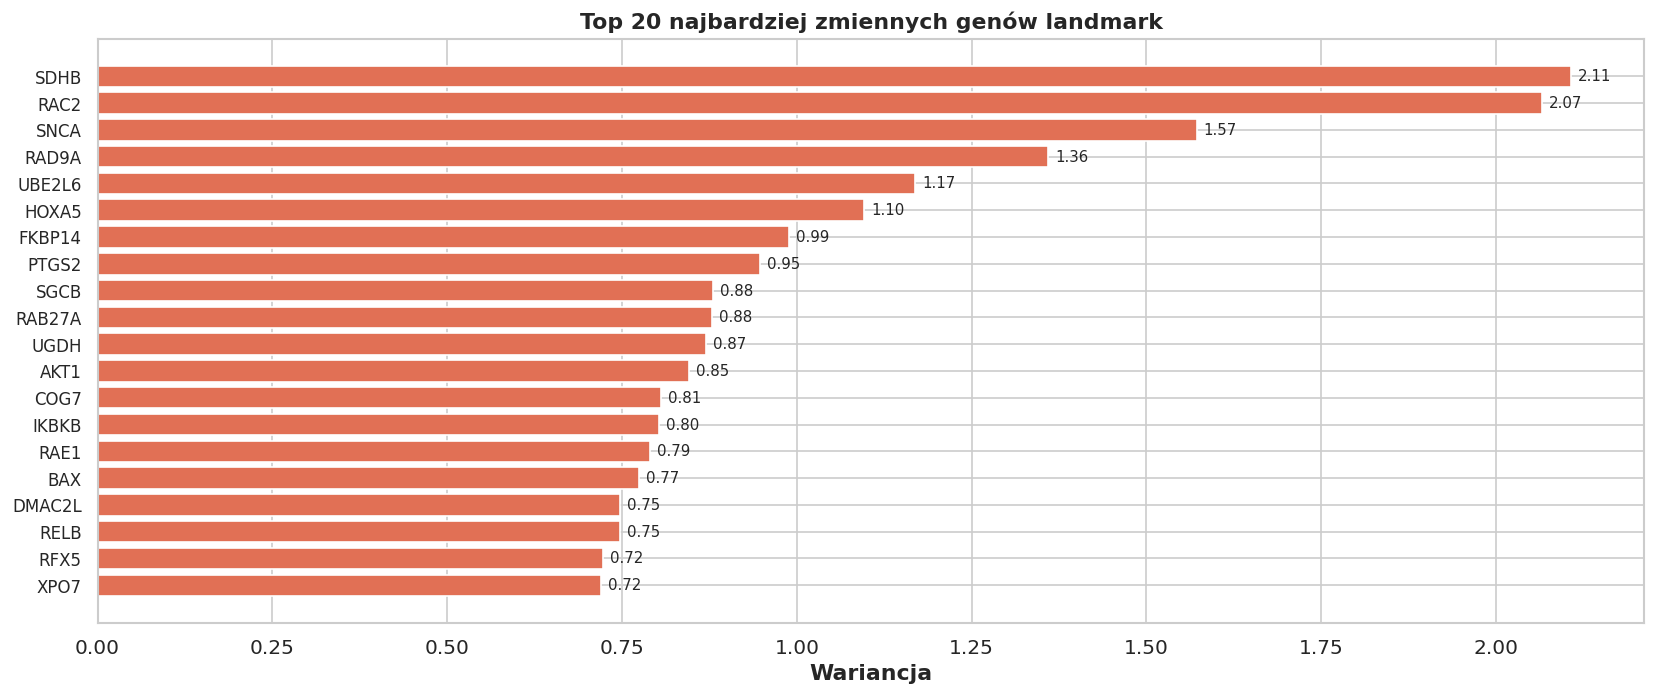

In [15]:
gene_var = np.var(ge_matrix, axis=0)
top_idx = np.argsort(gene_var)[::-1][:20]
top_genes = [ge_cols[i].replace('ge_', '') for i in top_idx]
top_vars = gene_var[top_idx]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(range(len(top_genes)), top_vars[::-1], color='#E17055', edgecolor='white')
ax.set_yticks(range(len(top_genes)))
ax.set_yticklabels(top_genes[::-1], fontsize=10)
ax.set_xlabel('Wariancja', fontweight='bold')
ax.set_title('Top 20 najbardziej zmiennych genów landmark', fontweight='bold')

for bar, val in zip(bars, top_vars[::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('datasets/lincs_eda_top_genes.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Macierz korelacji (top 30 najbardziej zmiennych genów)

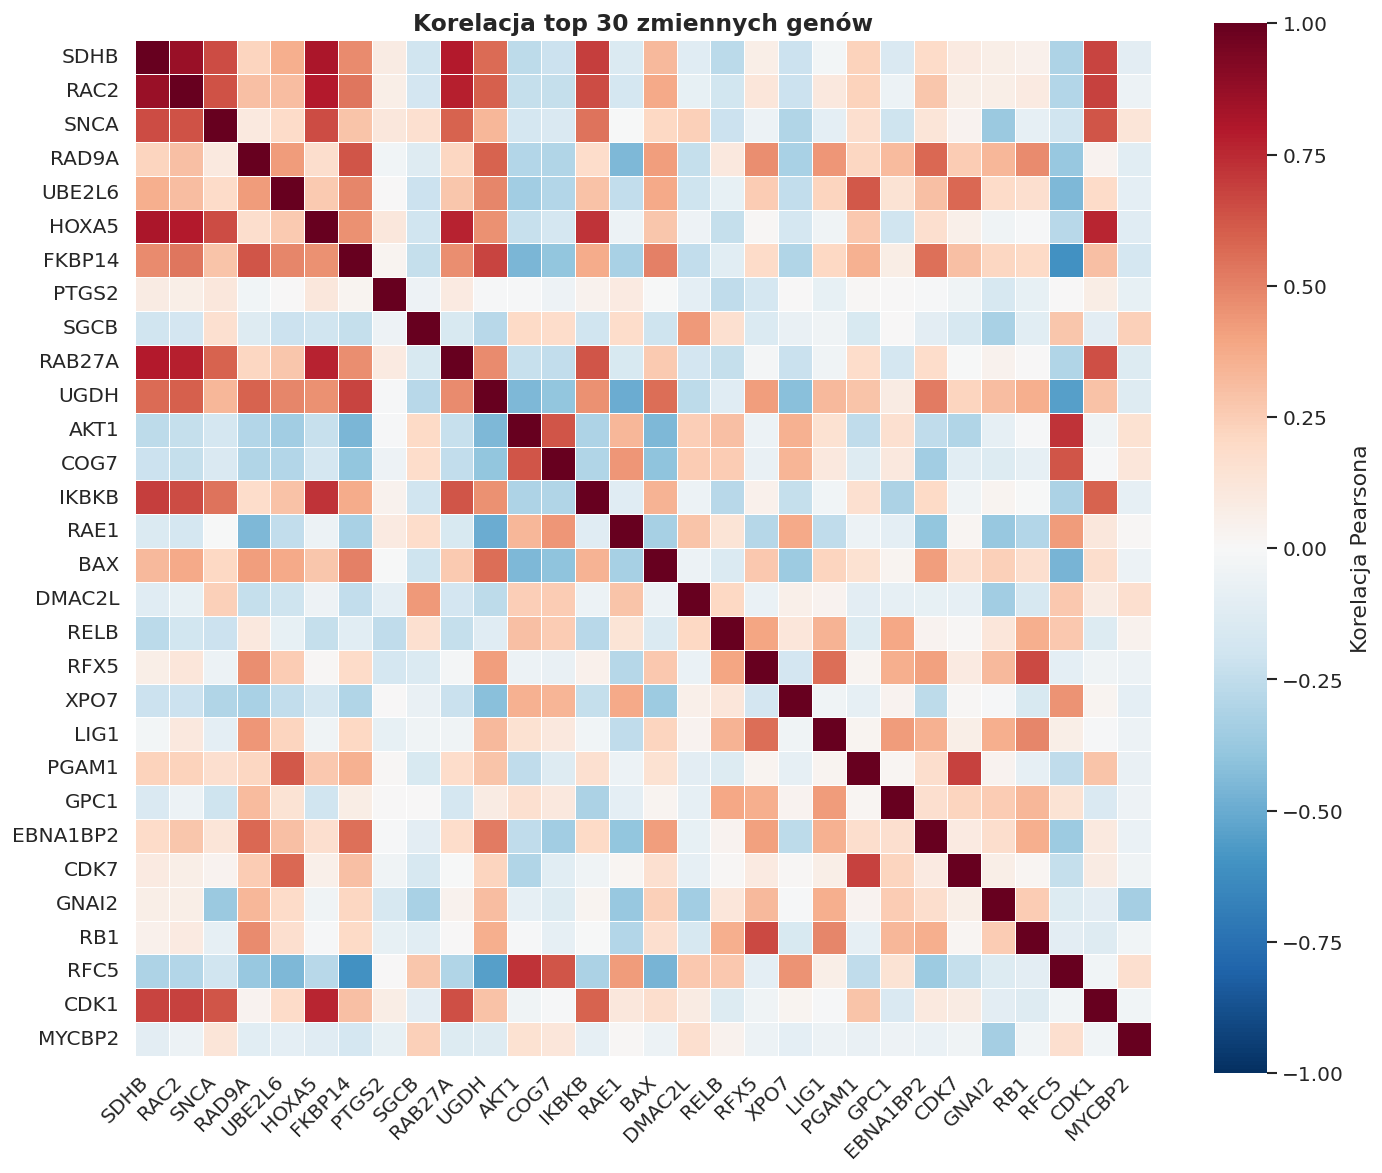

In [16]:
top30_idx = np.argsort(gene_var)[::-1][:30]
top30_names = [ge_cols[i].replace('ge_', '') for i in top30_idx]
top30_data = ge_matrix[:, top30_idx]

corr = np.corrcoef(top30_data.T)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, xticklabels=top30_names, yticklabels=top30_names,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Korelacja Pearsona'})
ax.set_title('Korelacja top 30 zmiennych genów', fontweight='bold', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('datasets/lincs_eda_corr.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA – redukcja wymiarowości profili GE

Wizualizacja 978-wymiarowych profili ekspresji w 2D za pomocą PCA, kolorowana aktywnością.

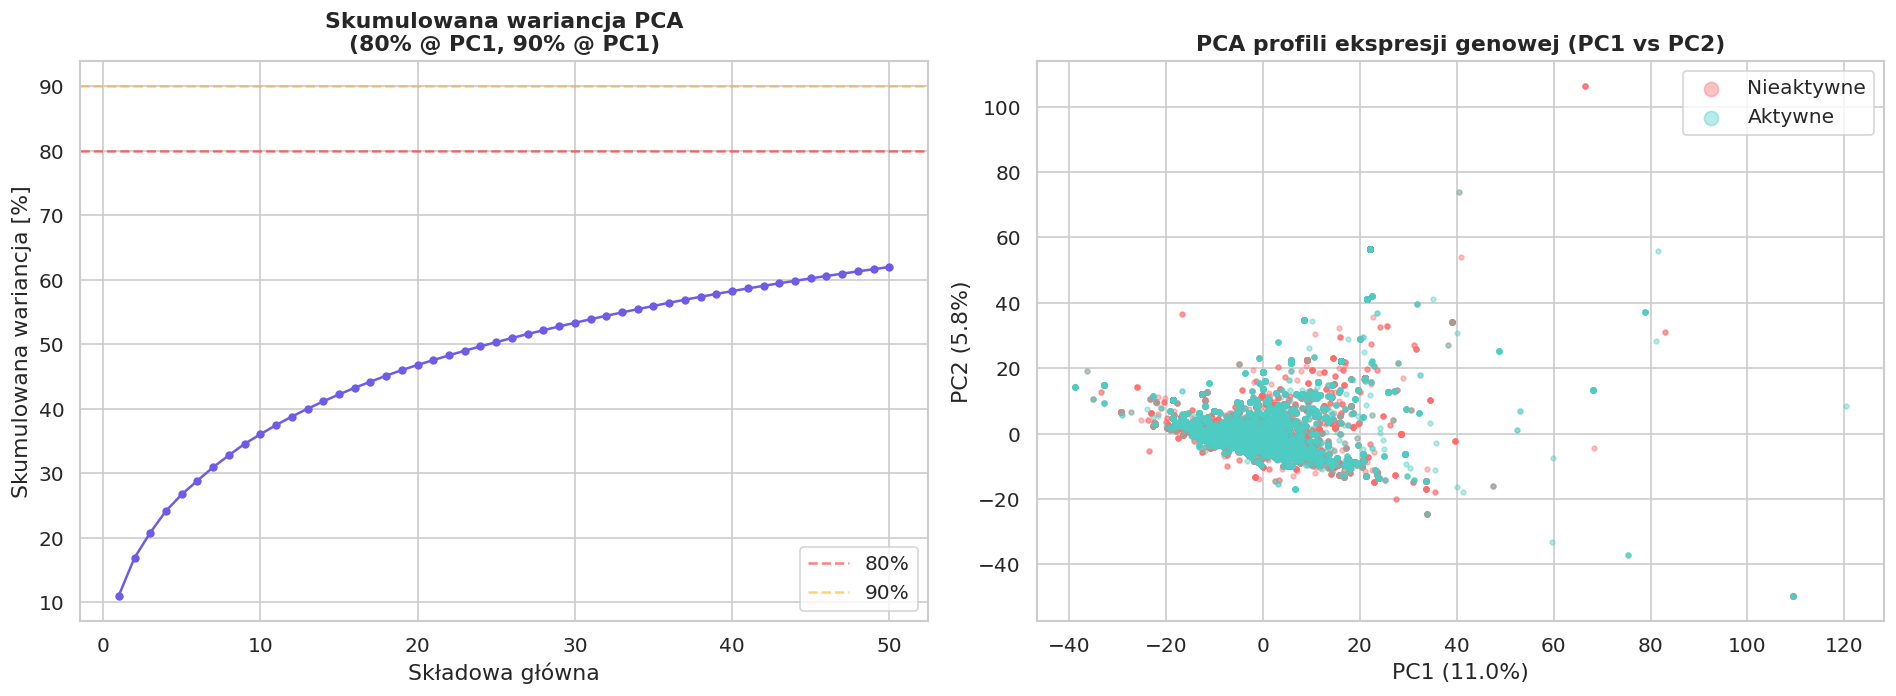

In [17]:
scaler = StandardScaler()
ge_scaled = scaler.fit_transform(ge_matrix)

pca = PCA(n_components=50)
ge_pca = pca.fit_transform(ge_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[0].plot(range(1, 51), cumvar, 'o-', color='#6C5CE7', markersize=4)
axes[0].axhline(80, color='red', linestyle='--', alpha=0.5, label='80%')
axes[0].axhline(90, color='orange', linestyle='--', alpha=0.5, label='90%')
n80 = np.argmax(cumvar >= 80) + 1
n90 = np.argmax(cumvar >= 90) + 1
axes[0].set_title(f'Skumulowana wariancja PCA\n(80% @ PC{n80}, 90% @ PC{n90})', fontweight='bold')
axes[0].set_xlabel('Składowa główna')
axes[0].set_ylabel('Skumulowana wariancja [%]')
axes[0].legend()

# 2D scatter
is_active = df['is_active'].to_numpy()
for label, mask, color, marker in [('Nieaktywne', ~is_active, '#FF6B6B', 'o'),
                                    ('Aktywne', is_active, '#4ECDC4', 'o')]:
    axes[1].scatter(ge_pca[mask, 0], ge_pca[mask, 1], c=color, s=8, alpha=0.4, label=label)
axes[1].set_title('PCA profili ekspresji genowej (PC1 vs PC2)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('datasets/lincs_eda_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. t-SNE wizualizacja (na PCA top 30 komponentów)

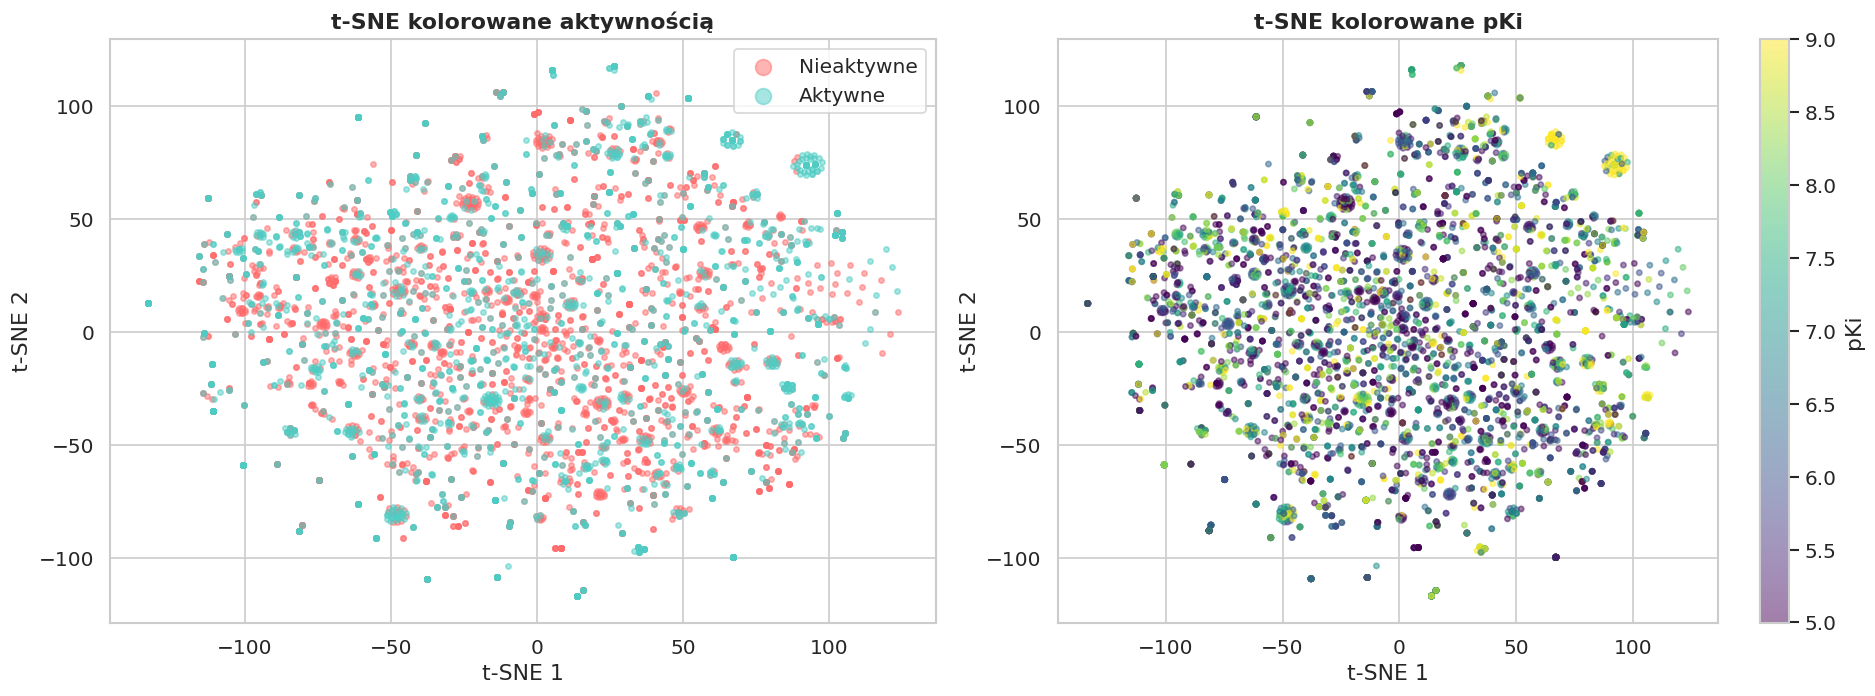

In [19]:
# t-SNE on PCA-reduced data for speed
np.random.seed(42)
n_sample = min(5000, ge_pca.shape[0])
idx = np.random.choice(ge_pca.shape[0], n_sample, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
ge_tsne = tsne.fit_transform(ge_pca[idx, :30])
labels_sample = is_active[idx]
pki_sample = df['pKi'].to_numpy()[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, mask, color in [('Nieaktywne', ~labels_sample, '#FF6B6B'),
                            ('Aktywne', labels_sample, '#4ECDC4')]:
    axes[0].scatter(ge_tsne[mask, 0], ge_tsne[mask, 1], c=color, s=10, alpha=0.5, label=label)
axes[0].set_title('t-SNE kolorowane aktywnością', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

sc = axes[1].scatter(ge_tsne[:, 0], ge_tsne[:, 1], c=pki_sample, cmap='viridis',
                     s=10, alpha=0.5, vmin=5, vmax=9)
plt.colorbar(sc, ax=axes[1], label='pKi')
axes[1].set_title('t-SNE kolorowane pKi', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('datasets/lincs_eda_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Rozkład par per lek i per białko

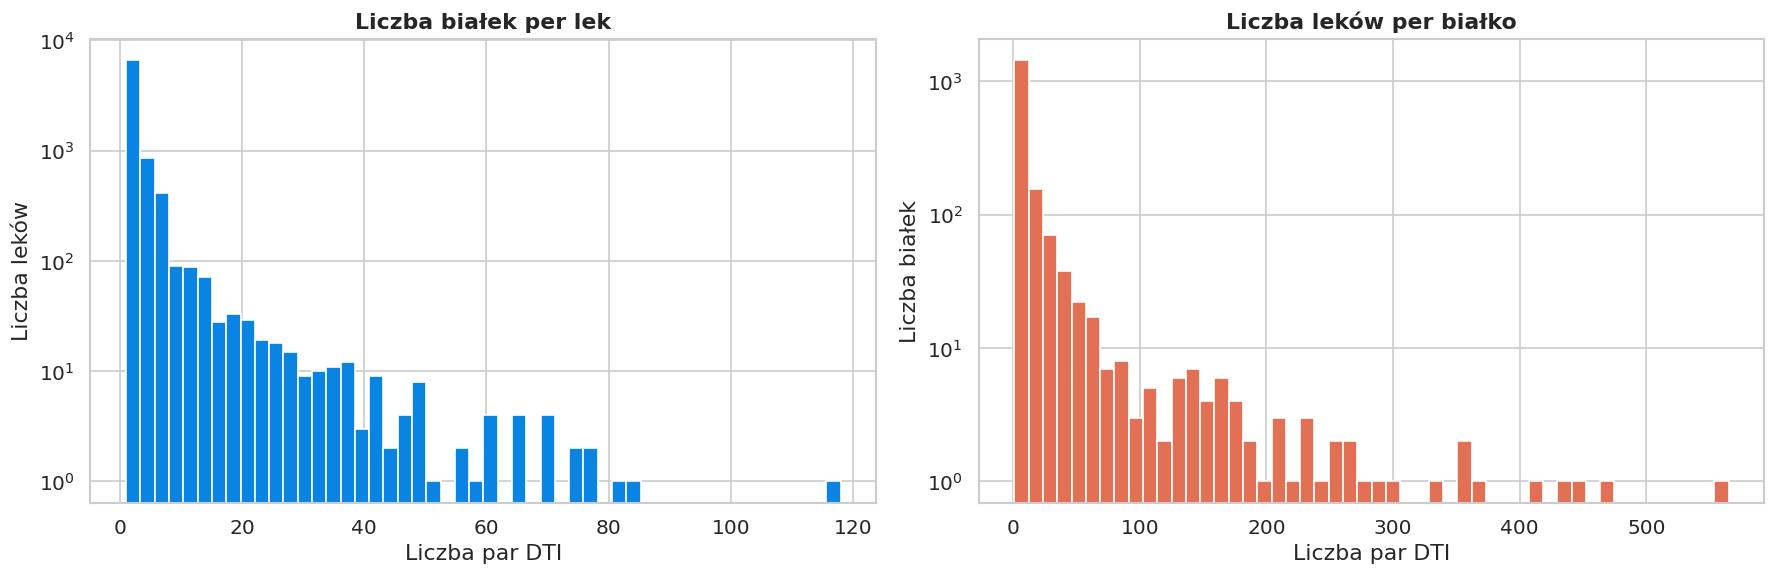

Mediana par per lek:   2.0
Mediana par per białko: 3.0

Top 10 leków z największą liczbą par:
shape: (10, 2)
┌─────────────────────────────────┬─────┐
│ Ligand SMILES                   ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ c1cc(ccc1C(=O)CCCN2CCC(CC2)(c3… ┆ 118 │
│ COC(=O)[C@@H]1C[C@H](OC(C)=O)C… ┆ 83  │
│ CCc1c(nn(c1-c1ccc(Br)cc1)-c1cc… ┆ 82  │
│ CC1=C(C(=O)N2CCCCC2=N1)CCN3CCC… ┆ 78  │
│ COc1ccc(cc1)C(CN(C)C)C1(O)CCCC… ┆ 77  │
│ Nc1ncnc2nc(cc(-c3cccc(Br)c3)c1… ┆ 75  │
│ CCN1CCCC1CNC(=O)c1cc(c(N)cc1OC… ┆ 74  │
│ Cc1ccc(Cn2nc(cc2-c2ccc(Cl)c(C)… ┆ 71  │
│ c1cc(c(cc1C2=C(C(=O)c3c(cc(cc3… ┆ 71  │
│ OCCOCCN1CCN(CC1)C1=Nc2ccccc2Sc… ┆ 70  │
└─────────────────────────────────┴─────┘

Top 10 białek z największą liczbą par:
shape: (10, 2)
┌─────────────────────────────────┬─────┐
│ Protein (40 znaków)             ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u3

In [20]:
pairs_per_drug = df.group_by('Ligand SMILES').len().sort('len', descending=True)
pairs_per_protein = df.group_by('Full_Protein_Sequence').len().sort('len', descending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(pairs_per_drug['len'].to_numpy(), bins=50, color='#0984E3', edgecolor='white')
axes[0].set_title('Liczba białek per lek', fontweight='bold')
axes[0].set_xlabel('Liczba par DTI')
axes[0].set_ylabel('Liczba leków')
axes[0].set_yscale('log')

axes[1].hist(pairs_per_protein['len'].to_numpy(), bins=50, color='#E17055', edgecolor='white')
axes[1].set_title('Liczba leków per białko', fontweight='bold')
axes[1].set_xlabel('Liczba par DTI')
axes[1].set_ylabel('Liczba białek')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('datasets/lincs_eda_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mediana par per lek:   {pairs_per_drug["len"].median()}')
print(f'Mediana par per białko: {pairs_per_protein["len"].median()}')
print(f'\nTop 10 leków z największą liczbą par:')
print(pairs_per_drug.head(10))
print(f'\nTop 10 białek z największą liczbą par:')
print(pairs_per_protein.select(pl.col('Full_Protein_Sequence').str.slice(0,40).alias('Protein (40 znaków)'), 'len').head(10))

## 10. Korelacja ekspresji genowej z aktywnością

Które geny landmark najsilniej korelują z pKi?

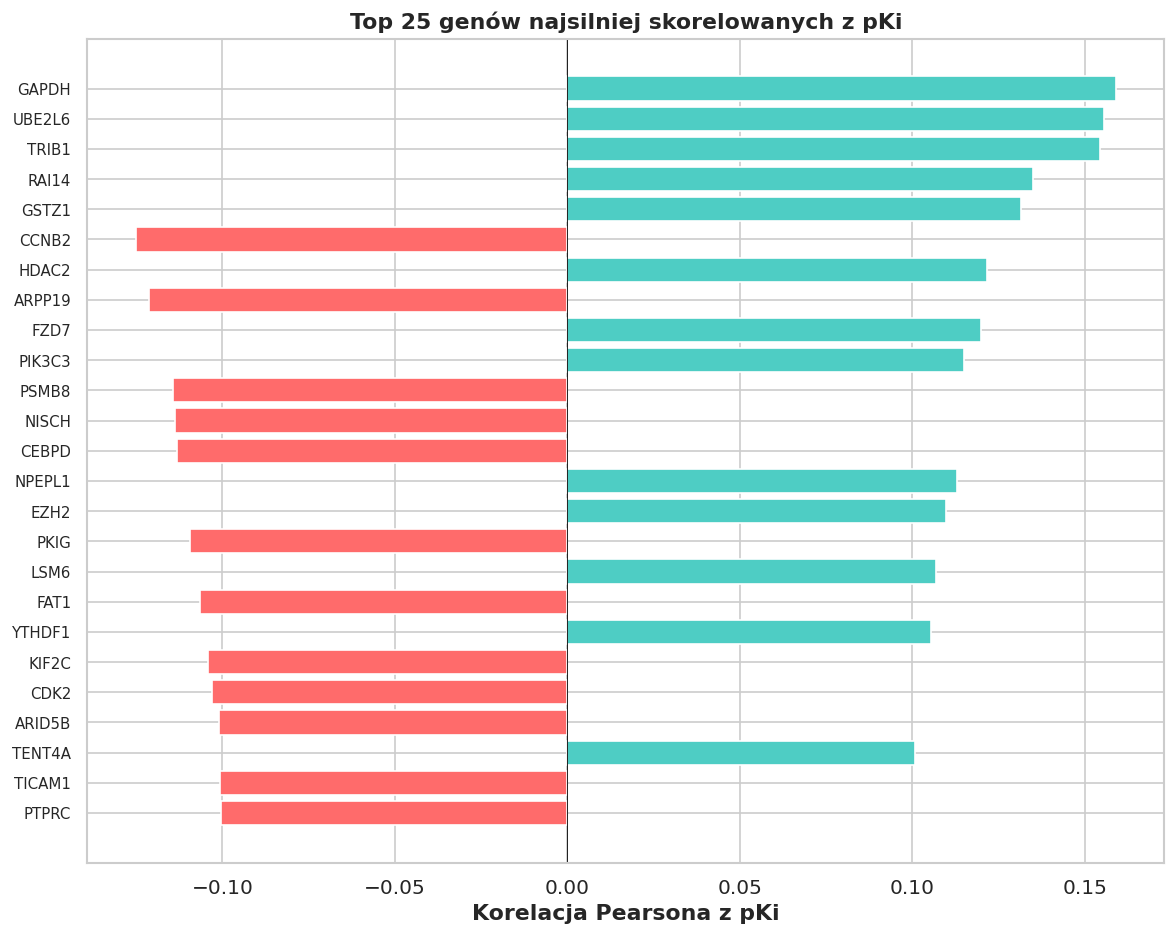


Top 10 genów pozytywnie skorelowanych z pKi:
            GAPDH  r = +0.1589
           UBE2L6  r = +0.1556
            TRIB1  r = +0.1545
            RAI14  r = +0.1350
            GSTZ1  r = +0.1316
            CCNB2  r = -0.1250
            HDAC2  r = +0.1216
           ARPP19  r = -0.1214
             FZD7  r = +0.1198
           PIK3C3  r = +0.1149


In [21]:
pki_vals = df['pKi'].to_numpy()
correlations = []
for j, col in enumerate(ge_cols):
    r = np.corrcoef(ge_matrix[:, j], pki_vals)[0, 1]
    correlations.append((col.replace('ge_', ''), r))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)

top_n = 25
top_corr = correlations[:top_n]
names = [c[0] for c in top_corr][::-1]
values = [c[1] for c in top_corr][::-1]
colors_bar = ['#4ECDC4' if v > 0 else '#FF6B6B' for v in values]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(names)), values, color=colors_bar, edgecolor='white')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Korelacja Pearsona z pKi', fontweight='bold')
ax.set_title(f'Top {top_n} genów najsilniej skorelowanych z pKi', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('datasets/lincs_eda_pki_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 10 genów pozytywnie skorelowanych z pKi:')
for name, r in correlations[:10]:
    print(f'  {name:>15s}  r = {r:+.4f}')